<a href="https://colab.research.google.com/github/JamilRez53/Adversarial-Attacks-on-forcasting/blob/main/Avdersarial_Robustness_Quantum_Encoded_Load_Forcasting_ISO_NE_Data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM-based Short-Term Load Forecasting
### (adapted for the Kaggle "ISO-NE Smart City Energy Dataset")

Implements the three classical (non-quantum) models described in:

> Sahay, K.B. & Singh, M. (2026). *"Quantum-Inspired Deep Learning Model for
> Short-Term Load Forecasting in Smart Grid Energy Management."* IEEE Access.

**Models implemented (in order of increasing sophistication):**
1. **Base LSTM** — single 64-unit LSTM layer + dense output
2. **Stacked LSTM** — 3 LSTM layers (64, 64, 128 units) in series
3. **Enhanced Stacked LSTM** — same as (2) + a normalization layer placed immediately before the final (128-unit) LSTM layer

> **Note:** The Quantum-Inspired Hadamard mixing step (QI-LSTM) is intentionally **not** implemented here, per request.

### Dataset
This notebook is wired up for the Kaggle dataset `datasetengineer/isone-smart-city-energy-dataset`,
downloaded via `kagglehub`. Its columns already include several of the paper's required
inputs pre-computed (hour, day-of-week, weekend flag), so the feature-engineering step
below reuses those instead of recomputing them, and only builds the lagged-load features
(24/48/72/168/336h) that aren't already present.

## 1. Download & inspect the dataset

In [1]:
import os
import kagglehub
import pandas as pd
# path = kagglehub.dataset_download("datasetengineer/isone-smart-city-energy-dataset")
df = pd.read_excel(
    '2025_smd_hourly.xlsx',
    sheet_name="ISO NE CA"
)

# print("Path to dataset files:", path)
# print("Files:", os.listdir(path))
# print(xls.sheet_names)
df.dtypes

,0
Date,datetime64[ns]
Hr_End,object
DA_Demand,float64
RT_Demand,float64
DA_LMP,float64
DA_EC,float64
DA_CC,float64
DA_MLC,float64
RT_LMP,float64
RT_EC,float64


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta

## 3. Config — column mapping for this dataset

In [3]:
DATE_COL = "Date"        # calendar date (midnight-stamped)
HREND_COL = "Hr_End"     # hour-ending label, string '01'..'24'
TS_COL = "Timestamp"     # constructed below: Date + (Hr_End - 1) hours

LOAD_COL = "System_Load"     # target to forecast (actual metered system load, MW)
DRYBULB_COL = "Dry_Bulb"
DEWPOINT_COL = "Dew_Point"

# Calendar features are NOT present in this file, so we derive them
# from the constructed Timestamp column instead of reusing dataset columns.
HOUR_COL = "Hour"
WEEKDAY_COL = "Weekday"
WEEKEND_COL = "IsWeekend"

# Train/test split. The paper used a fixed date-based split (Apr 2019-Dec 2023
# train / Jan-Dec 2024 test) on ISO-NE's multi-year data. This workbook only
# covers calendar year 2025, so we fall back to a chronological 80/20 split
# within the single year (still strictly time-ordered, no leakage).
TRAIN_FRAC = 0.80

LAG_HOURS = [24, 48, 72, 168, 336]   # matches the paper's lagged-load inputs
TIMESTEPS = 24                        # sequence length fed to the LSTM

# Training hyperparameters.
# NOTE: EPOCHS was 20 in the first run, but training loss was still falling
# monotonically at epoch 20 (all models undertrained), AND EarlyStopping was
# silently inert because fit() had no validation data for it to monitor
# ("UserWarning: Early stopping conditioned on metric `val_loss` which is not
# available"). VAL_SPLIT below fixes that, so EPOCHS can now be raised safely --
# early stopping will cut training off once validation loss stops improving.
EPOCHS = 60
BATCH_SIZE = 32
LEARNING_RATE = 0.001
VAL_SPLIT = 0.1   # Keras takes the LAST 10% of the (pre-shuffle) training
                  # array, which is chronologically the most recent window --
                  # appropriate for a time series.

## 4. Load data & check the date range

Run this first to confirm how much history the dataset actually covers, then decide
whether to use a fixed date-based split (like the paper) or the fallback chronological
fraction split above.

In [4]:
raw = pd.read_excel(
    '2025_smd_hourly.xlsx',
    sheet_name="ISO NE CA"
)
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL])

# Hr_End is normally '01'..'24', but ISO-NE marks the repeated hour on the
# DST "fall back" day with a trailing 'X' (e.g. '02X') -- strip any non-digit
# characters before casting to int.
raw["_hour_int"] = (
    raw[HREND_COL].astype(str).str.extract(r"(\d+)")[0].astype(int)
)

# Hour-ending 24 == 23:00-24:00 of the same calendar day -> hour-of-day 23
raw[TS_COL] = raw[DATE_COL] + pd.to_timedelta(raw["_hour_int"] - 1, unit="h")

# The DST fall-back duplicate ('02X') produces a repeated Timestamp -- keep the
# first occurrence so the series stays one-row-per-hour.
raw = raw.sort_values(TS_COL).drop_duplicates(subset=[TS_COL]).reset_index(drop=True)

raw[HOUR_COL] = raw[TS_COL].dt.hour
raw[WEEKDAY_COL] = raw[TS_COL].dt.dayofweek          # 0=Monday ... 6=Sunday
raw[WEEKEND_COL] = (raw[WEEKDAY_COL] >= 5).astype(int)

print("Rows:", len(raw))
print("Date range:", raw[TS_COL].min(), "to", raw[TS_COL].max())
raw

Rows: 8759
Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00


,Date,Hr_End,DA_Demand,RT_Demand,DA_LMP,DA_EC,DA_CC,DA_MLC,RT_LMP,RT_EC,...,Reg_Capacity_Price,Min_5min_RSP,Max_5min_RSP,Min_5min_RCP,Max_5min_RCP,_hour_int,Timestamp,Hour,Weekday,IsWeekend
0,2025-01-01,01,11020.2,11169.703,37.21,37.17,0.0,0.04,55.69,55.51,...,37.500000,0.00,0.01,0.00,50.00,1,2025-01-01 00:00:00,0,2,0
1,2025-01-01,02,10939.3,10788.139,35.09,35.02,0.0,0.07,41.96,41.78,...,8.333333,0.00,0.01,0.00,50.00,2,2025-01-01 01:00:00,1,2,0
2,2025-01-01,03,10302.3,10457.288,31.62,31.58,0.0,0.04,33.31,33.17,...,0.000000,0.00,0.00,0.00,0.00,3,2025-01-01 02:00:00,2,2,0
3,2025-01-01,04,10113.9,10266.686,30.05,30.00,0.0,0.05,32.53,32.38,...,0.000000,0.00,0.00,0.00,0.00,4,2025-01-01 03:00:00,3,2,0
4,2025-01-01,05,9979.7,10295.384,28.57,28.50,0.0,0.07,31.70,31.51,...,0.000000,0.00,0.00,0.00,0.00,5,2025-01-01 04:00:00,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8754,2025-12-31,20,16484.8,16411.900,178.17,177.94,0.0,0.23,80.23,79.86,...,8.008333,0.00,0.05,0.00,9.61,20,2025-12-31 19:00:00,19,2,0
8755,2025-12-31,21,15979.7,15805.841,173.12,172.86,0.0,0.26,78.63,78.26,...,8.030833,0.05,0.05,7.84,9.61,21,2025-12-31 20:00:00,20,2,0
8756,2025-12-31,22,15331.4,15206.881,151.55,151.42,0.0,0.13,84.82,84.42,...,16.853333,0.00,0.50,0.00,19.44,22,2025-12-31 21:00:00,21,2,0
8757,2025-12-31,23,14528.6,14544.393,144.01,143.90,0.0,0.11,78.47,78.11,...,11.808333,0.00,0.25,0.00,14.17,23,2025-12-31 22:00:00,22,2,0


**Data Visualization**

In [5]:
month_names = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

In [6]:
raw['Timestamp'] = pd.to_datetime(raw['Timestamp'])
raw['Year'] = raw['Timestamp'].dt.year
raw['Month'] = pd.to_datetime(raw['Timestamp']).dt.month

In [7]:
Columns = [LOAD_COL,DRYBULB_COL]
monthly_load = (
    raw.groupby(['Month','Year'])[Columns]
    .sum()
    .reset_index()
)
monthly_load['Month'] = monthly_load['Month'].apply(lambda x: month_names[x-1])
monthly_load

,Month,Year,System_Load,Dry_Bulb
0,January,2025,11389413,20065
1,February,2025,9960154,19364
2,March,2025,9329877,30221
3,April,2025,8255730,35721
4,May,2025,8423961,43252
5,June,2025,9978016,49690
6,July,2025,12180867,55616
7,August,2025,10329589,51572
8,September,2025,8827744,46611
9,October,2025,8654289,40157


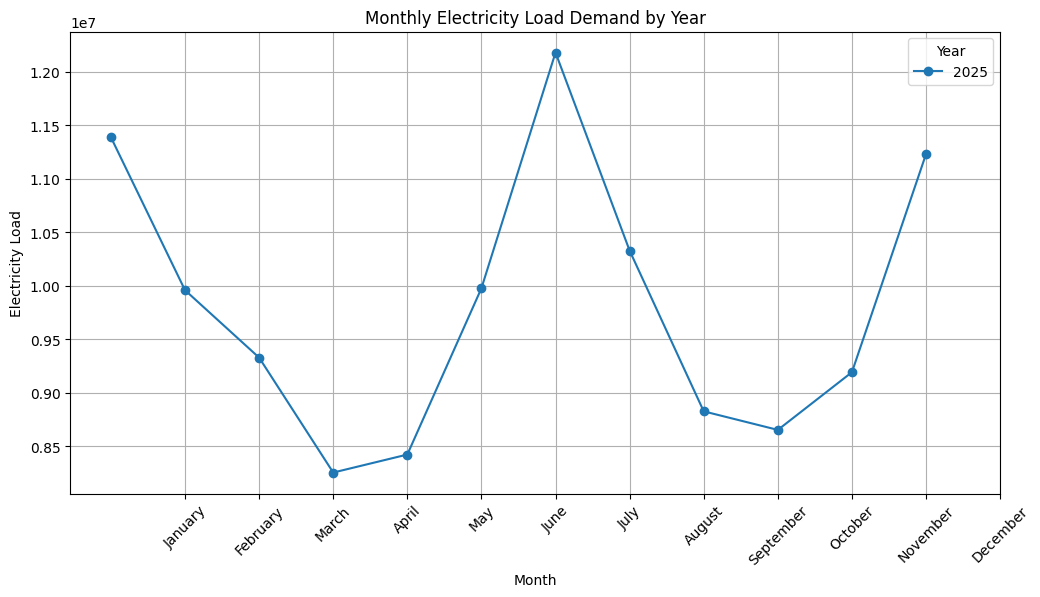

In [8]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

for year in monthly_load['Year'].unique():

    yearly_data = monthly_load[
        monthly_load['Year'] == year
    ]

    plt.plot(
        yearly_data['Month'],
        yearly_data[LOAD_COL],
        marker='o',
        label=str(year)
    )

plt.xlabel('Month')
plt.ylabel('Electricity Load')
plt.title('Monthly Electricity Load Demand by Year')

plt.xticks(
    range(1, 13),
    month_names,
    rotation=45
)

plt.legend(title='Year')
plt.grid(True)

plt.show()

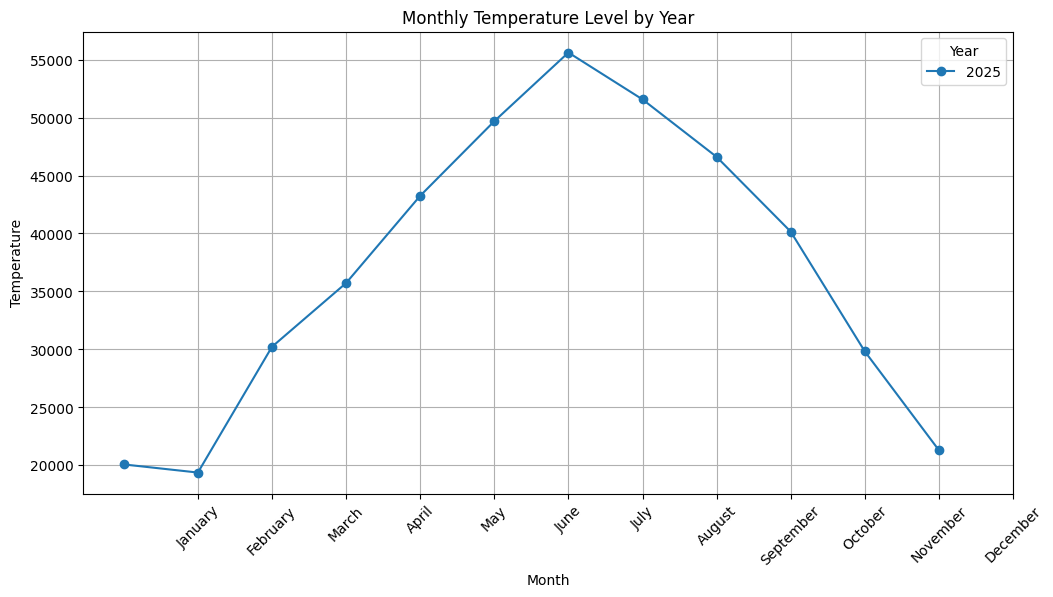

In [9]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

for year in monthly_load['Year'].unique():

    yearly_data = monthly_load[
        monthly_load['Year'] == year
    ]

    plt.plot(
        yearly_data['Month'],
        yearly_data[DRYBULB_COL],
        marker='o',
        label=str(year)
    )

plt.xlabel('Month')
plt.ylabel('Temperature')
plt.title('Monthly Temperature Level by Year')

plt.xticks(
    range(1, 13),
    month_names,
    rotation=45
)

plt.legend(title='Year')
plt.grid(True)

plt.show()

## 5. Feature engineering

In [10]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Reuse the dataset's existing calendar columns and add lagged-load features."""
    df = df.copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    for lag in LAG_HOURS:
        df[f"load_lag_{lag}h"] = df[LOAD_COL].shift(lag)

    df = df.dropna(subset=[f"load_lag_{lag}h" for lag in LAG_HOURS] + [LOAD_COL, DRYBULB_COL, DEWPOINT_COL])
    df = df.reset_index(drop=True)
    return df


FEATURE_COLS = [DRYBULB_COL, DEWPOINT_COL, HOUR_COL, WEEKDAY_COL, WEEKEND_COL] + [
    f"load_lag_{lag}h" for lag in LAG_HOURS
]

df = build_features(raw)
print("Rows after lag dropna:", len(df))
df[FEATURE_COLS + [LOAD_COL]].head()

Rows after lag dropna: 8423


,Dry_Bulb,Dew_Point,Hour,Weekday,IsWeekend,load_lag_24h,load_lag_48h,load_lag_72h,load_lag_168h,load_lag_336h,System_Load
0,29,6,13,2,0,14520.0,15533.0,13879.0,16338.0,11402.0,15096
1,21,9,22,2,0,15181.0,15853.0,14688.0,17178.0,11777.0,15522
2,22,8,21,2,0,16255.0,16618.0,15938.0,18340.0,12510.0,16618
3,22,8,20,2,0,17139.0,17346.0,16955.0,19183.0,13387.0,17461
4,23,8,19,2,0,17696.0,17159.0,16899.0,19073.0,14103.0,18018


## 6. Train/test split

In [11]:
# Chronological split (adjust to fixed dates if the range matches the paper's window)
split_idx = int(len(df) * TRAIN_FRAC)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Train rows: {len(train_df)}   ({train_df[DATE_COL].min()} to {train_df[DATE_COL].max()})")
print(f"Test rows:  {len(test_df)}   ({test_df[DATE_COL].min()} to {test_df[DATE_COL].max()})")

Train rows: 6738   (2025-01-15 00:00:00 to 2025-10-22 00:00:00)
Test rows:  1685   (2025-10-22 00:00:00 to 2025-12-31 00:00:00)


## 7. Normalization & sequence helpers

In [12]:
def zscore_fit(train_arr: np.ndarray):
    mu = train_arr.mean(axis=0)
    sigma = train_arr.std(axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma


def zscore_apply(arr: np.ndarray, mu, sigma):
    return (arr - mu) / sigma


def zscore_inverse(arr: np.ndarray, mu, sigma):
    return arr * sigma + mu


def make_sequences(X: np.ndarray, y: np.ndarray, timesteps: int = 24):
    """Turn a flat feature matrix into overlapping sequences for the LSTM."""
    Xs, ys = [], []
    for i in range(timesteps, len(X)):
        Xs.append(X[i - timesteps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

## 8. Normalize & build sequences

In [13]:
X_train_raw = train_df[FEATURE_COLS].values.astype(float)
y_train_raw = train_df[LOAD_COL].values.reshape(-1, 1).astype(float)
X_test_raw = test_df[FEATURE_COLS].values.astype(float)
y_test_raw = test_df[LOAD_COL].values.reshape(-1, 1).astype(float)

# Z-score normalization (fit on train only, as in the paper)
x_mu, x_sigma = zscore_fit(X_train_raw)
y_mu, y_sigma = zscore_fit(y_train_raw)

X_train = zscore_apply(X_train_raw, x_mu, x_sigma)
y_train = zscore_apply(y_train_raw, y_mu, y_sigma).flatten()
X_test = zscore_apply(X_test_raw, x_mu, x_sigma)
y_test = zscore_apply(y_test_raw, y_mu, y_sigma).flatten()

X_train_seq, y_train_seq = make_sequences(X_train, y_train, TIMESTEPS)
X_test_seq, y_test_seq = make_sequences(X_test, y_test, TIMESTEPS)

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
print("Input shape:", input_shape)
print("Train sequences:", X_train_seq.shape, " Test sequences:", X_test_seq.shape)

Input shape: (24, 10)
Train sequences: (6714, 24, 10)  Test sequences: (1661, 24, 10)


In [14]:
import tensorflow as tf

def fgsm_attack_tf(model, X, y_true, eps, feature_mask=None):
    X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y_true.reshape(-1, 1), dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_tf)
        pred = model(X_tf, training=False)
        loss = tf.keras.losses.MeanSquaredError()(y_tf, pred)

    grad = tape.gradient(loss, X_tf)
    if feature_mask is not None:
        grad = grad * feature_mask  # zero out gradient on features you don't want touched

    X_adv = X_tf + eps * tf.sign(grad)
    return X_adv.numpy()


def pgd_attack_tf(model, X, y_true, eps, alpha, iters, feature_mask=None, direction="mse"):
    X_orig = tf.convert_to_tensor(X, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y_true.reshape(-1, 1), dtype=tf.float32)
    X_adv = tf.identity(X_orig)

    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(X_adv)
            pred = model(X_adv, training=False)
            if direction == "under":       # push predictions BELOW true load
                loss = tf.reduce_mean(tf.nn.relu(y_tf - pred))
            elif direction == "over":      # push predictions ABOVE true load
                loss = tf.reduce_mean(tf.nn.relu(pred - y_tf))
            else:                          # generic degradation
                loss = tf.keras.losses.MeanSquaredError()(y_tf, pred)

        grad = tape.gradient(loss, X_adv)
        if feature_mask is not None:
            grad = grad * feature_mask

        X_adv = X_adv + alpha * tf.sign(grad)
        perturbation = tf.clip_by_value(X_adv - X_orig, -eps, eps)
        X_adv = X_orig + perturbation

    return X_adv.numpy()

In [15]:
def hadamard_mix(X: np.ndarray) -> np.ndarray:
    """Apply the paper's pairwise Hadamard mixing (Eq. 1-2) to a 2D array of
    Z-score-normalized features, shape (n_samples, n_features).

    For each consecutive feature pair (x_2i-1, x_2i):
        x'_2i-1 = (x_2i-1 + x_2i) / sqrt(2)
        x'_2i   = (x_2i-1 - x_2i) / sqrt(2)

    If n_features is odd, the last column is passed through unchanged.
    This is parameter-free and norm-preserving (an orthogonal transform).
    """
    X = np.asarray(X, dtype=float)
    n_samples, n_features = X.shape
    X_mixed = X.copy()

    n_pairs = n_features // 2
    for i in range(n_pairs):
        a = X[:, 2 * i]
        b = X[:, 2 * i + 1]
        X_mixed[:, 2 * i] = (a + b) / np.sqrt(2)
        X_mixed[:, 2 * i + 1] = (a - b) / np.sqrt(2)
    # odd leftover feature (not the case here: n_features == 10) is left as-is

    return X_mixed


# Sanity check: Hadamard mixing preserves the Euclidean norm of each row
_sample = X_train[:5]
_mixed_sample = hadamard_mix(_sample)
print("Norms before:", np.linalg.norm(_sample, axis=1))
print("Norms after: ", np.linalg.norm(_mixed_sample, axis=1))

# Apply to the full (already normalized) train/test feature matrices
X_train_qi = hadamard_mix(X_train)
X_test_qi = hadamard_mix(X_test)

X_train_seq_qi, y_train_seq_qi = make_sequences(X_train_qi, y_train, TIMESTEPS)
X_test_seq_qi, y_test_seq_qi = make_sequences(X_test_qi, y_test, TIMESTEPS)

print("QI-mixed train sequences:", X_train_seq_qi.shape, " test sequences:", X_test_seq_qi.shape)


Norms before: [3.0061918  3.65085105 3.95392545 4.28525967 4.24779838]
Norms after:  [3.0061918  3.65085105 3.95392545 4.28525967 4.24779838]
QI-mixed train sequences: (6714, 24, 10)  test sequences: (1661, 24, 10)


In [16]:
import numpy as np

def build_hadamard_matrix(n_features):
    """Build the orthogonal matrix H such that X @ H == hadamard_mix(X)."""
    H = np.zeros((n_features, n_features), dtype=np.float32)
    n_pairs = n_features // 2
    for i in range(n_pairs):
        a, b = 2*i, 2*i+1
        H[a, a] = 1/np.sqrt(2); H[b, a] = 1/np.sqrt(2)
        H[a, b] = 1/np.sqrt(2); H[b, b] = -1/np.sqrt(2)
    if n_features % 2 == 1:
        H[-1, -1] = 1.0
    return tf.constant(H)

H_matrix = build_hadamard_matrix(input_shape[1])  # (n_features, n_features)

def qi_model_fn(model, X_raw):
    """Composes Hadamard mixing + QI-LSTM into one differentiable call."""
    X_mixed = tf.matmul(X_raw, H_matrix)  # applies along feature axis, per timestep
    return model(X_mixed, training=False)

## 9. Metrics (Equations 5, 6, 7 in the paper)

In [17]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)


def evaluate(y_true, y_pred, name):
    m, a, r = mape(y_true, y_pred), mae(y_true, y_pred), r2(y_true, y_pred)
    print(f"[{name}] MAPE = {m:.4f}%   MAE = {a:.4f} kW   R2 = {r:.4f}")
    return {"model": name, "MAPE (%)": m, "MAE (kW)": a, "R2": r}

## 10. Model architectures

In [18]:
def build_base_lstm(input_shape):
    """Single 64-unit LSTM layer + dense regression output (~19,265 params)."""
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model


def build_stacked_lstm(input_shape):
    """Three LSTM layers (64, 64, 128 units) in series (~151,169 params)."""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(64, return_sequences=True),
        LSTM(128),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model


def build_enhanced_stacked_lstm(input_shape):
    """Stacked LSTM + normalization layer placed immediately before the
    final (128-unit) LSTM layer (~151,297 params)."""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        LSTM(128),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model

def build_qi_lstm(input_shape):
    """QI-LSTM: identical backbone to the Enhanced Stacked LSTM (64, 64, 128
    units + normalization before the last LSTM layer), but fed Hadamard-mixed
    input features instead of the raw normalized ones. The Hadamard mixing
    itself adds zero trainable parameters, so this model has the same
    ~151,297 parameters as the Enhanced Stacked LSTM.
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        LSTM(128),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model

In [19]:
def adversarial_pattern(model, x, y, loss_fn=tf.keras.losses.MeanSquaredError()):
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x)
        prediction = model(x, training=False)
        loss = loss_fn(y, prediction)

    gradient = tape.gradient(loss, x)
    signed_grad = tf.sign(gradient)
    return signed_grad

## 11. Train & evaluate all three models

In [20]:
model_specs = {
    "Base LSTM (64 units)": (build_base_lstm(input_shape), X_train_seq, y_train_seq, X_test_seq, y_test_seq),
    "Stacked LSTM (64,64,128)": (build_stacked_lstm(input_shape), X_train_seq, y_train_seq, X_test_seq, y_test_seq),
    "Enhanced Stacked LSTM": (build_enhanced_stacked_lstm(input_shape), X_train_seq, y_train_seq, X_test_seq, y_test_seq),
    "QI-LSTM (Hadamard mixing)": (build_qi_lstm(input_shape), X_train_seq_qi, y_train_seq_qi, X_test_seq_qi, y_test_seq_qi),
}

results = []
adv_results = []
epsilon = 0.01     # perturbation magnitude, in Z-score units

for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
    # A FRESH EarlyStopping per model. Reusing ONE instance across .fit() calls
    # leaks its internal `best` score between models: model 2 inherits model 1's
    # best val_loss, never beats it, and is killed after `patience` epochs.
    # (Observed: models 2-4 all died at exactly epoch 5, R2 collapsing to ~0.20.)
    early_stop = EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    print(f"\nTraining {name} ...")
    hist = model.fit(
        X_tr, y_tr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        shuffle=True,
        callbacks=[early_stop],
        verbose=1
    )
    print(f"  stopped after {len(hist.history['loss'])} epochs "
          f"(best val_loss = {min(hist.history['val_loss']):.5f})")

    # --- Clean evaluation ---
    y_pred_norm = model.predict(X_te, verbose=0).flatten()
    y_pred = zscore_inverse(y_pred_norm, y_mu[0], y_sigma[0])
    y_true = zscore_inverse(y_te, y_mu[0], y_sigma[0])
    results.append(evaluate(y_true, y_pred, name))

    # --- White-box FGSM ---
    X_te_adv = fgsm_attack_tf(model, X_te, y_te, eps=epsilon)
    y_pred_adv_norm = model.predict(X_te_adv, verbose=0).flatten()
    y_pred_adv = zscore_inverse(y_pred_adv_norm, y_mu[0], y_sigma[0])
    adv_results.append(evaluate(y_true, y_pred_adv, f"{name} (FGSM eps={epsilon})"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training Base LSTM (64 units) ...
Epoch 1/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3530 - val_loss: 0.1840
Epoch 2/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2328 - val_loss: 0.1823
Epoch 3/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2090 - val_loss: 0.1829
Epoch 4/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.2008 - val_loss: 0.1712
Epoch 5/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1902 - val_loss: 0.1718
Epoch 6/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1841 - val_loss: 0.1689
Epoch 7/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1748 - val_loss: 0.1630
Epoch 8/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1683 - val_loss: 0.1743
Epoch 9/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1651 - val_loss: 0.1544
Epoch 10/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1579 - val_loss: 0.1628
Epoch 11/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1562 - val_loss: 0.1726
Epoch 

### 11b. White-box PGD attack

FGSM above takes a single signed-gradient step. PGD repeats that step, re-clipping
to the eps-ball each time -- the stronger iterative white-box attack, and the
upper-bound reference for every black-box attack below.

This must run BEFORE section 12, which reports `pgd_results`.

In [21]:
pgd_alpha = epsilon / 4
pgd_iters = 10

pgd_results = []

for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
    y_true_te = zscore_inverse(y_te, y_mu[0], y_sigma[0])

    X_te_pgd = pgd_attack_tf(
        model, X_te, y_te, eps=epsilon, alpha=pgd_alpha, iters=pgd_iters
    )

    y_pred_pgd_norm = model.predict(X_te_pgd, verbose=0).flatten()
    y_pred_pgd = zscore_inverse(y_pred_pgd_norm, y_mu[0], y_sigma[0])
    pgd_results.append(
        evaluate(y_true_te, y_pred_pgd, f"{name} (PGD eps={epsilon}, iters={pgd_iters})")
    )

[Base LSTM (64 units) (PGD eps=0.01, iters=10)] MAPE = 7.8346%   MAE = 1070.8160 kW   R2 = 0.6252
[Stacked LSTM (64,64,128) (PGD eps=0.01, iters=10)] MAPE = 7.3549%   MAE = 1012.6752 kW   R2 = 0.6499
[Enhanced Stacked LSTM (PGD eps=0.01, iters=10)] MAPE = 7.7643%   MAE = 1082.0056 kW   R2 = 0.5965
[QI-LSTM (Hadamard mixing) (PGD eps=0.01, iters=10)] MAPE = 7.8131%   MAE = 1064.8374 kW   R2 = 0.6348


## 12. Summary

In [22]:
results_df = pd.DataFrame(results)
adv_results_df = pd.DataFrame(adv_results)      # white-box FGSM
pgd_results_df_raw = pd.DataFrame(pgd_results)  # white-box PGD (section 11b)

print("=== Summary (clean test set) ===")
print(results_df)

print("\n=== Summary (white-box FGSM) ===")
print(adv_results_df)

print("\n=== Summary (white-box PGD) ===")
print(pgd_results_df_raw)

adv_results_df_clean_names = adv_results_df.copy()
adv_results_df_clean_names["model"] = adv_results_df_clean_names["model"].str.replace(
    r"\s*\(FGSM.*\)", "", regex=True
)
pgd_results_df_clean_names = pgd_results_df_raw.copy()
pgd_results_df_clean_names["model"] = pgd_results_df_clean_names["model"].str.replace(
    r"\s*\(PGD.*\)", "", regex=True
)

metric_cols = [c for c in results_df.columns if c != "model"]

diff_df = results_df.merge(adv_results_df_clean_names, on="model", suffixes=("_clean", "_adv"))
for col in metric_cols:
    diff_df[f"{col}_diff"] = diff_df[f"{col}_adv"] - diff_df[f"{col}_clean"]
    diff_df[f"{col}_diff_%"] = (diff_df[f"{col}_diff"] / diff_df[f"{col}_clean"]) * 100

ordered_cols = ["model"]
for col in metric_cols:
    ordered_cols += [f"{col}_clean", f"{col}_adv", f"{col}_diff", f"{col}_diff_%"]
diff_df = diff_df[ordered_cols]

print("\n=== Metrics Difference: Clean vs White-box FGSM ===")
display(diff_df)

diff_df_pgd = results_df.merge(pgd_results_df_clean_names, on="model", suffixes=("_clean", "_adv"))
for col in metric_cols:
    diff_df_pgd[f"{col}_diff"] = diff_df_pgd[f"{col}_adv"] - diff_df_pgd[f"{col}_clean"]
    diff_df_pgd[f"{col}_diff_%"] = (diff_df_pgd[f"{col}_diff"] / diff_df_pgd[f"{col}_clean"]) * 100
diff_df_pgd = diff_df_pgd[ordered_cols]

print("\n=== Metrics Difference: Clean vs White-box PGD ===")
diff_df_pgd

=== Summary (clean test set) ===
                       model  MAPE (%)    MAE (kW)        R2
0       Base LSTM (64 units)  6.910780  947.617261  0.681035
1   Stacked LSTM (64,64,128)  6.495315  897.568722  0.700146
2      Enhanced Stacked LSTM  6.756707  946.605518  0.659820
3  QI-LSTM (Hadamard mixing)  6.975087  953.354732  0.684946

=== Summary (white-box FGSM) ===
                                       model  MAPE (%)     MAE (kW)        R2
0       Base LSTM (64 units) (FGSM eps=0.01)  7.833555  1070.681883  0.625219
1   Stacked LSTM (64,64,128) (FGSM eps=0.01)  7.354026  1012.559320  0.649982
2      Enhanced Stacked LSTM (FGSM eps=0.01)  7.760102  1081.445225  0.596806
3  QI-LSTM (Hadamard mixing) (FGSM eps=0.01)  7.811434  1064.615231  0.634855

=== Summary (white-box PGD) ===
                                               model  MAPE (%)     MAE (kW)  \
0      Base LSTM (64 units) (PGD eps=0.01, iters=10)  7.834584  1070.815999   
1  Stacked LSTM (64,64,128) (PGD eps=0.01, iter

,model,MAPE (%)_clean,MAPE (%)_adv,MAPE (%)_diff,MAPE (%)_diff_%,MAE (kW)_clean,MAE (kW)_adv,MAE (kW)_diff,MAE (kW)_diff_%,R2_clean,R2_adv,R2_diff,R2_diff_%
0,Base LSTM (64 units),6.910780,7.833555,0.922775,13.352685,947.617261,1070.681883,123.064622,12.986743,0.681035,0.625219,-0.055817,-8.195858
1,"Stacked LSTM (64,64,128)",6.495315,7.354026,0.858710,13.220458,897.568722,1012.559320,114.990598,12.811342,0.700146,0.649982,-0.050165,-7.164876
2,Enhanced Stacked LSTM,6.756707,7.760102,1.003395,14.850348,946.605518,1081.445225,134.839707,14.244551,0.659820,0.596806,-0.063014,-9.550230
3,QI-LSTM (Hadamard mixing),6.975087,7.811434,0.836346,11.990474,953.354732,1064.615231,111.260500,11.670420,0.684946,0.634855,-0.050090,-7.313061



=== Metrics Difference: Clean vs White-box PGD ===


,model,MAPE (%)_clean,MAPE (%)_adv,MAPE (%)_diff,MAPE (%)_diff_%,MAE (kW)_clean,MAE (kW)_adv,MAE (kW)_diff,MAE (kW)_diff_%,R2_clean,R2_adv,R2_diff,R2_diff_%
0,Base LSTM (64 units),6.910780,7.834584,0.923804,13.367582,947.617261,1070.815999,123.198738,13.000896,0.681035,0.625155,-0.055880,-8.205163
1,"Stacked LSTM (64,64,128)",6.495315,7.354903,0.859587,13.233957,897.568722,1012.675151,115.106429,12.824247,0.700146,0.649927,-0.050219,-7.172674
2,Enhanced Stacked LSTM,6.756707,7.764267,1.007560,14.911999,946.605518,1082.005564,135.400046,14.303746,0.659820,0.596513,-0.063307,-9.594567
3,QI-LSTM (Hadamard mixing),6.975087,7.813136,0.838048,12.014879,953.354732,1064.837364,111.482632,11.693720,0.684946,0.634752,-0.050193,-7.328067


## 13. Black-box attacks

In a **black-box** setting the attacker cannot see the target model's weights or
gradients. We implement the two canonical black-box strategies used in the
adversarial-ML-for-load-forecasting literature, following:

> Chen, Y., Tan, Y. & Zhang, B. (2019). *"Exploiting Vulnerabilities of Load
> Forecasting Through Adversarial Attacks."* Proceedings of the 10th ACM
> International Conference on Future Energy Systems (e-Energy '19).
> [arXiv:1904.06606](https://arxiv.org/abs/1904.06606)

**13a. Transfer attack ("learn-and-attack")** — the paper's core threat model:
the attacker has *no* access to the target model's parameters and *no* query
access either, only a historical dataset with the same features. The attacker
trains their own **substitute model**, crafts a white-box FGSM/PGD attack
against it (reusing the `fgsm_attack_tf`/`pgd_attack_tf` helpers from
section 8), and transfers those perturbed inputs to the real target models.
The paper shows this transfers with high success even though the substitute
and target never share weights.

**13b. Query-based attack (SPSA)** — a complementary, stronger black-box
threat model where the attacker *can* query the target model's predictions
(but still not its gradients or weights). We estimate a gradient direction
purely from input/output pairs using **Simultaneous Perturbation Stochastic
Approximation (SPSA)** — a standard gradient-free optimizer used for
black-box adversarial attacks on sequence/RNN models (Uesato et al., 2018,
*"Adversarial Risk and the Dangers of Evaluating Against Weak Attacks"*).

### 13a. Transfer attack via a substitute model

In [23]:
def build_substitute_model(input_shape):
    """Attacker's stand-in model, deliberately a *different* architecture from
    any of the four targets (single 32-unit LSTM + small dense head), trained
    only on the historical data the attacker is assumed to have. This is the
    'substitute'/'surrogate' from Chen et al. (2019) -- the attacker never sees
    the target models' weights or gradients."""
    model = Sequential([
        LSTM(32, input_shape=input_shape),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model


substitute_model = build_substitute_model(input_shape)
print("Training substitute (surrogate) model on the attacker's available data ...")

# Own EarlyStopping instance -- never share one across .fit() calls (see the
# training loop above for what goes wrong).
sub_early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
sub_hist = substitute_model.fit(
    X_train_seq, y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    shuffle=True,
    callbacks=[sub_early_stop],
    verbose=1,
)
print(f"  stopped after {len(sub_hist.history['loss'])} epochs "
      f"(best val_loss = {min(sub_hist.history['val_loss']):.5f})")

y_pred_sub_norm = substitute_model.predict(X_test_seq, verbose=0).flatten()
y_pred_sub = zscore_inverse(y_pred_sub_norm, y_mu[0], y_sigma[0])
y_true = zscore_inverse(y_test_seq, y_mu[0], y_sigma[0])
_ = evaluate(y_true, y_pred_sub, "Substitute model (clean, for reference)")

Training substitute (surrogate) model on the attacker's available data ...
Epoch 1/60


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.3954 - val_loss: 0.2098
Epoch 2/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2482 - val_loss: 0.1849
Epoch 3/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2175 - val_loss: 0.1878
Epoch 4/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2065 - val_loss: 0.1815
Epoch 5/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1939 - val_loss: 0.1785
Epoch 6/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1879 - val_loss: 0.1716
Epoch 7/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1834 - val_loss: 0.1675
Epoch 8/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1770 - val_loss: 0.1663
Epoch 9/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1719 - val_loss: 0.1674
Epoch 10/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1706 - val_loss: 0.1714
Epoch 11/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1658 - val_loss: 0.1617
Epoch 12/60
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/ste

In [24]:
# --- Trainable parameter counts (info only) ---
_param_models = dict(list(model_specs.items()) + [("Substitute (32-unit LSTM)", (substitute_model, None, None, None, None))])

print(f"{'Model':<30}{'Trainable':>14}{'Non-trainable':>16}{'Total':>14}")
print("-" * 74)
for name, (m, *_rest) in _param_models.items():
    trainable = int(sum(int(np.prod(w.shape)) for w in m.trainable_weights))
    non_trainable = int(sum(int(np.prod(w.shape)) for w in m.non_trainable_weights))
    print(f"{name:<30}{trainable:>14,}{non_trainable:>16,}{trainable + non_trainable:>14,}")

del _param_models

Model                              Trainable   Non-trainable         Total
--------------------------------------------------------------------------
Base LSTM (64 units)                  19,265               0        19,265
Stacked LSTM (64,64,128)             151,169               0       151,169
Enhanced Stacked LSTM                151,297             128       151,425
QI-LSTM (Hadamard mixing)            151,297             128       151,425
Substitute (32-unit LSTM)              6,049               0         6,049


In [25]:
# Craft the attack against the SUBSTITUTE only (this is the only model the
# attacker is allowed to see gradients of). eps matches the white-box FGSM
# run in section 11 so the two are directly comparable.
transfer_eps = epsilon  # 0.01, defined in section 11

X_test_adv_transfer = fgsm_attack_tf(
    substitute_model, X_test_seq, y_test_seq, eps=transfer_eps
)

print("Crafted transfer-attack inputs using the substitute model's gradients only.")
print("Perturbed test sequences:", X_test_adv_transfer.shape)

Crafted transfer-attack inputs using the substitute model's gradients only.
Perturbed test sequences: (1661, 24, 10)


In [26]:
def _prep_for_model(name, X_adv):
    if name == "QI-LSTM (Hadamard mixing)":
        return np.stack([hadamard_mix(seq) for seq in X_adv])
    return X_adv

transfer_results = []
for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
    y_pred_adv_norm = model.predict(_prep_for_model(name, X_test_adv_transfer), verbose=0).flatten()
    y_pred_adv = zscore_inverse(y_pred_adv_norm, y_mu[0], y_sigma[0])
    transfer_results.append(
        evaluate(y_true, y_pred_adv, f"{name} (Transfer BB, eps={transfer_eps})")
    )

[Base LSTM (64 units) (Transfer BB, eps=0.01)] MAPE = 7.2155%   MAE = 988.7022 kW   R2 = 0.6574
[Stacked LSTM (64,64,128) (Transfer BB, eps=0.01)] MAPE = 6.7418%   MAE = 931.0455 kW   R2 = 0.6810
[Enhanced Stacked LSTM (Transfer BB, eps=0.01)] MAPE = 6.9738%   MAE = 976.6405 kW   R2 = 0.6414
[QI-LSTM (Hadamard mixing) (Transfer BB, eps=0.01)] MAPE = 7.2142%   MAE = 985.2482 kW   R2 = 0.6666


In [27]:
X_test_adv_transfer_pgd = pgd_attack_tf(
    substitute_model, X_test_seq, y_test_seq,
    eps=epsilon, alpha=epsilon / 4, iters=pgd_iters,
)

def _prep_for_model(name, X_adv):
    if name == "QI-LSTM (Hadamard mixing)":
        return np.stack([hadamard_mix(seq) for seq in X_adv])
    return X_adv

transfer_results_pgd = []
for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
    y_pred_pgd_norm = model.predict(_prep_for_model(name, X_test_adv_transfer_pgd), verbose=0).flatten()
    y_pred_pgd = zscore_inverse(y_pred_pgd_norm, y_mu[0], y_sigma[0])
    transfer_results_pgd.append(
        evaluate(y_true, y_pred_pgd, f"{name} (Transfer PGD BB, eps={epsilon})")
    )

[Base LSTM (64 units) (Transfer PGD BB, eps=0.01)] MAPE = 7.2152%   MAE = 988.6557 kW   R2 = 0.6574
[Stacked LSTM (64,64,128) (Transfer PGD BB, eps=0.01)] MAPE = 6.7419%   MAE = 931.0606 kW   R2 = 0.6810
[Enhanced Stacked LSTM (Transfer PGD BB, eps=0.01)] MAPE = 6.9738%   MAE = 976.6473 kW   R2 = 0.6414
[QI-LSTM (Hadamard mixing) (Transfer PGD BB, eps=0.01)] MAPE = 7.2142%   MAE = 985.2599 kW   R2 = 0.6666


### 13b. Query-based black-box attack (SPSA)

SPSA estimates the loss gradient with only two forward-pass queries per
coordinate-batch, by perturbing the input in a random `+/-1` direction
`delta` and using the *finite difference* in the model's loss:

```
g_hat approx  ( L(x + c*delta) - L(x - c*delta) ) / (2c)  *  delta
```

No gradient tape, no access to weights -- only `model.predict(...)` calls.
This is much more expensive (many queries per example) but works against a
strictly query-only API, unlike the transfer attack above.

In [28]:
def spsa_attack(model, X, y_true, eps, alpha=0.01, iters=40, samples_per_iter=8):
    """Gradient-free SPSA attack: estimates the sign of the loss gradient
    using only model.predict (no gradient tape), then takes a PGD-style
    signed step, clipped to an eps-ball around the original input.

    X, y_true: numpy arrays (already Z-score normalized), shapes
        X: (n, timesteps, n_features), y_true: (n,)
    eps: max L_inf perturbation (same scale as the white-box attacks)
    alpha: step size per iteration
    iters: number of SPSA iterations
    samples_per_iter: number of random +/-1 perturbation directions averaged
        per iteration (more samples = less noisy gradient estimate, more
        queries)
    """
    mse = tf.keras.losses.MeanSquaredError()
    X_orig = tf.convert_to_tensor(X, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y_true.reshape(-1, 1), dtype=tf.float32)
    X_adv = tf.identity(X_orig)
    c = 0.01  # SPSA perturbation size for the finite-difference probe

    for _ in range(iters):
        grad_estimate = tf.zeros_like(X_adv)
        for _ in range(samples_per_iter):
            delta = tf.sign(tf.random.uniform(tf.shape(X_adv), -1, 1))
            pred_plus = model(X_adv + c * delta, training=False)
            pred_minus = model(X_adv - c * delta, training=False)
            loss_plus = mse(y_tf, pred_plus)
            loss_minus = mse(y_tf, pred_minus)
            grad_estimate += (loss_plus - loss_minus) / (2 * c) * delta
        grad_estimate /= samples_per_iter

        X_adv = X_adv + alpha * tf.sign(grad_estimate)
        perturbation = tf.clip_by_value(X_adv - X_orig, -eps, eps)
        X_adv = X_orig + perturbation

    n_queries = iters * samples_per_iter * 2 * len(X)
    return X_adv.numpy(), n_queries

In [29]:
# Query-only black-box attack. Two fairness fixes vs. the first run:
#   1. eps now MATCHES the white-box/transfer attacks (0.01). Previously SPSA
#      ran at 3x the budget (0.03), which quietly flattered it.
#   2. subset widened 200 -> 600 rows, since the measured SPSA effect
#      (~1-2% relative MAPE) was the same order of magnitude as the sampling
#      noise from n=200.
# The gradient-free estimate is noisier than a true gradient, so we compensate
# with iterations rather than with a bigger eps.
#
# SPEED TRIM (this run only): iters 80->30, samples_per_iter 8->4.
# That's 1280 -> 240 forward passes per model (~5.3x fewer queries), traded
# for a noisier gradient estimate. eps and the 600-row subset are UNCHANGED
# -- those were deliberate fairness fixes (see above) and stay put. Expect
# the SPSA MAPE numbers to be a bit noisier / possibly slightly weaker than
# a full 80-iter run would show; treat this pass as directional, and bump
# iters back up for a final reproducible number if the trend looks interesting.
np.random.seed(0)
spsa_n_eval = 600
spsa_idx = np.random.choice(len(X_test_seq), size=min(spsa_n_eval, len(X_test_seq)), replace=False)
X_spsa_subset = X_test_seq[spsa_idx]
y_spsa_subset = y_test_seq[spsa_idx]
y_true_spsa = zscore_inverse(y_spsa_subset, y_mu[0], y_sigma[0])

# QI-LSTM is queried in its own (Hadamard-mixed) input space, since SPSA talks
# to the target model directly rather than going through a raw-feature surrogate.
X_spsa_subset_qi = np.stack([hadamard_mix(seq) for seq in X_spsa_subset])

spsa_eps = epsilon          # matched to every other attack
spsa_alpha = 0.005
spsa_iters = 30            # trimmed from 80 for speed (see note above)
spsa_samples_per_iter = 4  # trimmed from 8 for speed (see note above)

spsa_results = []
for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
    X_query_input = X_spsa_subset_qi if name == "QI-LSTM (Hadamard mixing)" else X_spsa_subset
    print(f"Running SPSA on {name} ...")
    X_adv_spsa, n_queries = spsa_attack(
        model, X_query_input, y_spsa_subset,
        eps=spsa_eps, alpha=spsa_alpha, iters=spsa_iters,
        samples_per_iter=spsa_samples_per_iter,
    )
    y_pred_adv_norm = model.predict(X_adv_spsa, verbose=0).flatten()
    y_pred_adv = zscore_inverse(y_pred_adv_norm, y_mu[0], y_sigma[0])
    spsa_results.append(evaluate(y_true_spsa, y_pred_adv, f"{name} (SPSA BB, eps={spsa_eps})"))

# Clean baseline on the SAME subset -- the only valid reference for the SPSA
# rows, since R2/MAE are sample-dependent and the other attacks use the full set.
spsa_clean_results = []
for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
    X_clean_input = X_spsa_subset_qi if name == "QI-LSTM (Hadamard mixing)" else X_spsa_subset
    y_pred_norm = model.predict(X_clean_input, verbose=0).flatten()
    y_pred = zscore_inverse(y_pred_norm, y_mu[0], y_sigma[0])
    spsa_clean_results.append(evaluate(y_true_spsa, y_pred, f"{name} (clean, SPSA subset)"))

Running SPSA on Base LSTM (64 units) ...
[Base LSTM (64 units) (SPSA BB, eps=0.01)] MAPE = 7.1046%   MAE = 981.0937 kW   R2 = 0.6689
Running SPSA on Stacked LSTM (64,64,128) ...
[Stacked LSTM (64,64,128) (SPSA BB, eps=0.01)] MAPE = 6.5299%   MAE = 910.5038 kW   R2 = 0.6965
Running SPSA on Enhanced Stacked LSTM ...
[Enhanced Stacked LSTM (SPSA BB, eps=0.01)] MAPE = 6.9150%   MAE = 977.3158 kW   R2 = 0.6482
Running SPSA on QI-LSTM (Hadamard mixing) ...
[QI-LSTM (Hadamard mixing) (SPSA BB, eps=0.01)] MAPE = 6.9533%   MAE = 958.3867 kW   R2 = 0.6855
[Base LSTM (64 units) (clean, SPSA subset)] MAPE = 7.0882%   MAE = 978.9276 kW   R2 = 0.6701
[Stacked LSTM (64,64,128) (clean, SPSA subset)] MAPE = 6.5214%   MAE = 909.3995 kW   R2 = 0.6972
[Enhanced Stacked LSTM (clean, SPSA subset)] MAPE = 6.9043%   MAE = 975.8253 kW   R2 = 0.6492
[QI-LSTM (Hadamard mixing) (clean, SPSA subset)] MAPE = 6.9455%   MAE = 957.3772 kW   R2 = 0.6864


## 14. Combined summary — white-box vs. transfer (black-box) vs. SPSA (black-box)

In [30]:
def _to_named_df(records, strip_pattern, suffix):
    d = pd.DataFrame(records)
    d["model"] = d["model"].str.replace(strip_pattern, "", regex=True)
    d = d.add_suffix(f"_{suffix}").rename(columns={f"model_{suffix}": "model"})
    return d

pgd_wb_df = _to_named_df(pgd_results, r"\s*\(PGD.*\)", "whiteboxPGD")
transfer_fgsm_df = _to_named_df(transfer_results, r"\s*\(Transfer BB.*\)", "transferFGSM")
transfer_pgd_df = _to_named_df(transfer_results_pgd, r"\s*\(Transfer PGD.*\)", "transferPGD")
spsa_clean_df = _to_named_df(spsa_clean_results, r"\s*\(clean.*\)", "spsaCleanSubset")
spsa_df = _to_named_df(spsa_results, r"\s*\(SPSA BB.*\)", "spsaBB")

combined = (
    results_df.add_suffix("_clean").rename(columns={"model_clean": "model"})
    .merge(adv_results_df_clean_names.add_suffix("_whiteboxFGSM").rename(columns={"model_whiteboxFGSM": "model"}), on="model")
    .merge(pgd_wb_df, on="model")
    .merge(transfer_fgsm_df, on="model")
    .merge(transfer_pgd_df, on="model")
    .merge(spsa_clean_df, on="model")
    .merge(spsa_df, on="model")
)

print("=== Clean vs White-box (FGSM/PGD) vs Transfer black-box (FGSM/PGD) vs SPSA black-box ===")
combined

=== Clean vs White-box (FGSM/PGD) vs Transfer black-box (FGSM/PGD) vs SPSA black-box ===


,model,MAPE (%)_clean,MAE (kW)_clean,R2_clean,MAPE (%)_whiteboxFGSM,MAE (kW)_whiteboxFGSM,R2_whiteboxFGSM,MAPE (%)_whiteboxPGD,MAE (kW)_whiteboxPGD,R2_whiteboxPGD,...,R2_transferFGSM,MAPE (%)_transferPGD,MAE (kW)_transferPGD,R2_transferPGD,MAPE (%)_spsaCleanSubset,MAE (kW)_spsaCleanSubset,R2_spsaCleanSubset,MAPE (%)_spsaBB,MAE (kW)_spsaBB,R2_spsaBB
0,Base LSTM (64 units),6.910780,947.617261,0.681035,7.833555,1070.681883,0.625219,7.834584,1070.815999,0.625155,...,0.657423,7.215199,988.655689,0.657432,7.088248,978.927586,0.670142,7.104629,981.093731,0.668909
1,"Stacked LSTM (64,64,128)",6.495315,897.568722,0.700146,7.354026,1012.559320,0.649982,7.354903,1012.675151,0.649927,...,0.680974,6.741940,931.060635,0.680984,6.521437,909.399525,0.697196,6.529895,910.503797,0.696473
2,Enhanced Stacked LSTM,6.756707,946.605518,0.659820,7.760102,1081.445225,0.596806,7.764267,1082.005564,0.596513,...,0.641408,6.973813,976.647289,0.641441,6.904261,975.825323,0.649241,6.914990,977.315838,0.648216
3,QI-LSTM (Hadamard mixing),6.975087,953.354732,0.684946,7.811434,1064.615231,0.634855,7.813136,1064.837364,0.634752,...,0.666561,7.214247,985.259878,0.666574,6.945526,957.377234,0.686419,6.953258,958.386655,0.685495


### Visualize: MAPE degradation by attack type

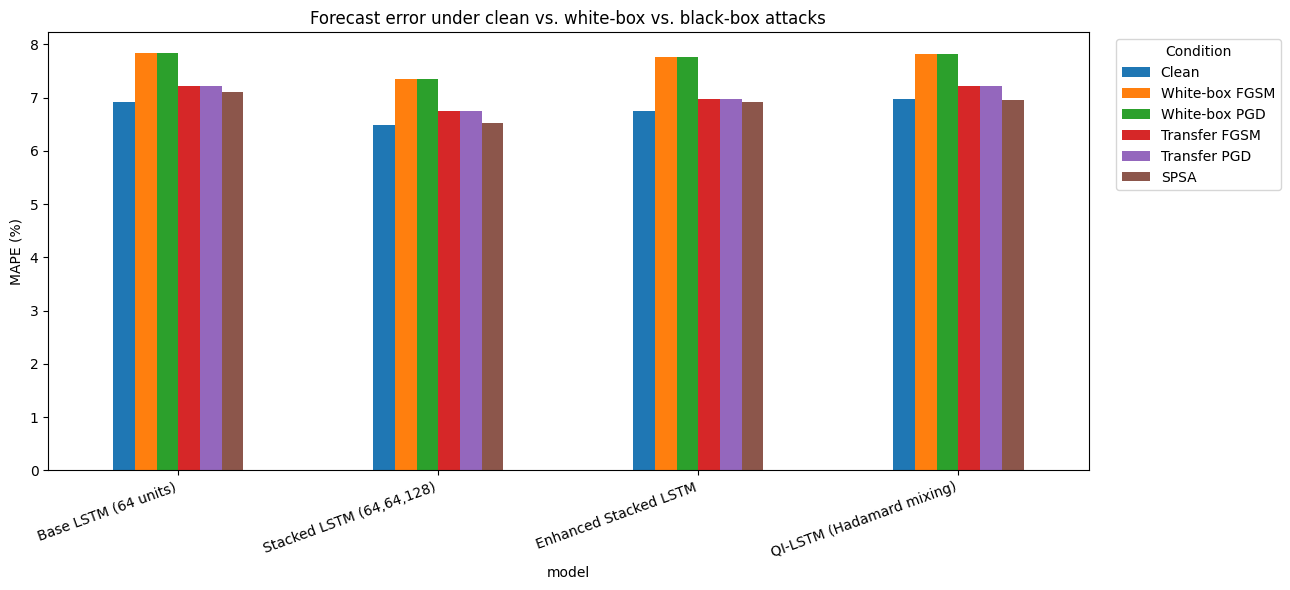

In [31]:
plot_df = combined[[
    "model", "MAPE (%)_clean", "MAPE (%)_whiteboxFGSM", "MAPE (%)_whiteboxPGD",
    "MAPE (%)_transferFGSM", "MAPE (%)_transferPGD", "MAPE (%)_spsaBB",
]].set_index("model")
plot_df.columns = ["Clean", "White-box FGSM", "White-box PGD", "Transfer FGSM", "Transfer PGD", "SPSA"]
ax = plot_df.plot(kind="bar", figsize=(13, 6))
ax.set_ylabel("MAPE (%)")
ax.set_title("Forecast error under clean vs. white-box vs. black-box attacks")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 15. Feature-injection attack (weather channel only)

Everything above lets the attacker perturb **all ten input features**, including
the lagged metered load. That is unrealistic: metered load comes from the
utility's own SCADA/AMI infrastructure, which an outside attacker cannot rewrite.

The threat model in Chen et al. (2019) is narrower and far more practical:

> "By only injecting malicious data in temperature from online weather forecast
> APIs, an attacker could manipulate load forecasts..."
>
> — Chen, Tan & Zhang, *Exploiting Vulnerabilities of Load Forecasting Through
> Adversarial Attacks*, e-Energy '19 ([arXiv:1904.06606](https://arxiv.org/abs/1904.06606))

Weather feeds are third-party, public, and comparatively soft targets, so the
adversary is restricted to the **weather channel** (`Dry_Bulb`, `Dew_Point`) and
cannot touch calendar or lagged-load features at all. We implement this with the
`feature_mask` argument that `fgsm_attack_tf`/`pgd_attack_tf` already accept
(defined in section 8 but unused until now) — the mask zeroes the gradient on
every feature the attacker is not allowed to write to.

We report three variants:
- **White-box, untargeted** — maximize forecast error, weather features only.
- **Black-box, untargeted** — same mask, but crafted on the substitute model and
  transferred (the actual Chen et al. setting: no target gradients at all).
- **White-box, targeted "under-forecast"** — push predictions *below* true load,
  the operationally dangerous direction (under-forecasting risks under-committed
  generation and load shedding). Uses `direction="under"` in `pgd_attack_tf`.

Because only 2 of 10 features can move, we sweep a range of larger budgets and
report each one in **degrees Fahrenheit**, so the perturbation can be judged for
physical plausibility rather than as an abstract Z-score.

In [32]:
# FEATURE_COLS order: [Dry_Bulb, Dew_Point, Hour, Weekday, IsWeekend, lag24, lag48, lag72, lag168, lag336]
WEATHER_IDX = [FEATURE_COLS.index(DRYBULB_COL), FEATURE_COLS.index(DEWPOINT_COL)]
print("Attacker may only write to feature indices", WEATHER_IDX,
      "->", [FEATURE_COLS[i] for i in WEATHER_IDX])

# Mask broadcasts over (n_samples, timesteps, n_features): 1 = writable, 0 = frozen.
weather_mask = np.zeros((1, 1, input_shape[1]), dtype=np.float32)
weather_mask[..., WEATHER_IDX] = 1.0
weather_mask = tf.constant(weather_mask)

# Convert a Z-score budget into degrees F, using the training-set sigma for
# Dry_Bulb, so the perturbation sizes below are physically interpretable.
drybulb_sigma_F = x_sigma[WEATHER_IDX[0]]
print(f"Dry_Bulb training sigma = {drybulb_sigma_F:.2f} F  "
      f"(so eps=1.0 in Z-units == {drybulb_sigma_F:.1f} F of tampering)")

# NOTE on QI-LSTM: Hadamard mixing pairs features (0,1), (2,3), ... so Dry_Bulb
# and Dew_Point form exactly one closed pair and map back onto positions 0 and 1.
# Masking indices {0,1} therefore restricts the attacker to the weather channel
# in BOTH the raw and the mixed representation -- the comparison stays valid.

INJECTION_EPS = [0.1, 0.25, 0.5, 1.0]
print("\nSweeping injection budgets:",
      [f"{e} Z ({e * drybulb_sigma_F:.1f} F)" for e in INJECTION_EPS])

Attacker may only write to feature indices [0, 1] -> ['Dry_Bulb', 'Dew_Point']
Dry_Bulb training sigma = 17.87 F  (so eps=1.0 in Z-units == 17.9 F of tampering)

Sweeping injection budgets: ['0.1 Z (1.8 F)', '0.25 Z (4.5 F)', '0.5 Z (8.9 F)', '1.0 Z (17.9 F)']


In [33]:
# Sanity check: confirm the attack really left the non-weather features alone.
_probe = pgd_attack_tf(
    model_specs["Base LSTM (64 units)"][0], X_test_seq[:64], y_test_seq[:64],
    eps=1.0, alpha=0.25, iters=pgd_iters, feature_mask=weather_mask,
)
per_feature_max = np.abs(_probe - X_test_seq[:64]).max(axis=(0, 1))
print("Max |perturbation| per feature (should be > 0 ONLY for the weather channel):")
for col, v in zip(FEATURE_COLS, per_feature_max):
    flag = "  <-- writable" if col in (DRYBULB_COL, DEWPOINT_COL) else ""
    print(f"  {col:<16} {v:.6f}{flag}")
assert per_feature_max[[i for i in range(len(FEATURE_COLS)) if i not in WEATHER_IDX]].max() < 1e-6, \
    "Feature mask leaked -- non-weather features were modified!"
print("\nMask verified: only the weather channel was modified.")

Max |perturbation| per feature (should be > 0 ONLY for the weather channel):
  Dry_Bulb         1.000000  <-- writable
  Dew_Point        1.000000  <-- writable
  Hour             0.000000
  Weekday          0.000000
  IsWeekend        0.000000
  load_lag_24h     0.000000
  load_lag_48h     0.000000
  load_lag_72h     0.000000
  load_lag_168h    0.000000
  load_lag_336h    0.000000

Mask verified: only the weather channel was modified.


In [34]:
# NOTE: this sweeps 4 budgets x 4 models x 3 attack variants (~36 PGD runs
# over the full test set). Expect a few minutes on a Colab GPU, longer on CPU.
# Trim INJECTION_EPS above if you want a faster pass.
inj_wb, inj_bb, inj_targeted = [], [], []

for inj_eps in INJECTION_EPS:
    label_F = f"{inj_eps}Z/{inj_eps * drybulb_sigma_F:.1f}F"
    print(f"\n--- injection budget {label_F} ---")

    # Black-box: craft ONCE on the substitute (raw feature space), then transfer.
    X_inj_transfer = pgd_attack_tf(
        substitute_model, X_test_seq, y_test_seq,
        eps=inj_eps, alpha=inj_eps / 4, iters=pgd_iters,
        feature_mask=weather_mask,
    )

    for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
        y_true_te = zscore_inverse(y_te, y_mu[0], y_sigma[0])

        # (a) white-box, untargeted -- attacker has this model's gradients
        X_inj_wb = pgd_attack_tf(
            model, X_te, y_te,
            eps=inj_eps, alpha=inj_eps / 4, iters=pgd_iters,
            feature_mask=weather_mask,
        )
        p = zscore_inverse(model.predict(X_inj_wb, verbose=0).flatten(), y_mu[0], y_sigma[0])
        r = evaluate(y_true_te, p, f"{name} (Inject WB {label_F})")
        r["eps_Z"], r["eps_F"] = inj_eps, inj_eps * drybulb_sigma_F
        inj_wb.append(r)

        # (b) black-box transfer -- no target gradients (the Chen et al. setting)
        p = zscore_inverse(
            model.predict(_prep_for_model(name, X_inj_transfer), verbose=0).flatten(),
            y_mu[0], y_sigma[0])
        r = evaluate(y_true_te, p, f"{name} (Inject BB {label_F})")
        r["eps_Z"], r["eps_F"] = inj_eps, inj_eps * drybulb_sigma_F
        inj_bb.append(r)

        # (c) white-box, TARGETED under-forecast (push predictions below truth)
        X_inj_under = pgd_attack_tf(
            model, X_te, y_te,
            eps=inj_eps, alpha=inj_eps / 4, iters=pgd_iters,
            feature_mask=weather_mask, direction="under",
        )
        p_under = zscore_inverse(model.predict(X_inj_under, verbose=0).flatten(), y_mu[0], y_sigma[0])
        r = evaluate(y_true_te, p_under, f"{name} (Inject WB-under {label_F})")
        r["eps_Z"], r["eps_F"] = inj_eps, inj_eps * drybulb_sigma_F
        # mean signed bias in MW: negative => systematically under-forecasting
        r["mean_bias_MW"] = float(np.mean(p_under - y_true_te))
        inj_targeted.append(r)


--- injection budget 0.1Z/1.8F ---
[Base LSTM (64 units) (Inject WB 0.1Z/1.8F)] MAPE = 9.5445%   MAE = 1299.4194 kW   R2 = 0.5031
[Base LSTM (64 units) (Inject BB 0.1Z/1.8F)] MAPE = 8.1920%   MAE = 1120.7574 kW   R2 = 0.5798
[Base LSTM (64 units) (Inject WB-under 0.1Z/1.8F)] MAPE = 8.2304%   MAE = 1136.6140 kW   R2 = 0.5787
[Stacked LSTM (64,64,128) (Inject WB 0.1Z/1.8F)] MAPE = 8.9915%   MAE = 1233.4837 kW   R2 = 0.5341
[Stacked LSTM (64,64,128) (Inject BB 0.1Z/1.8F)] MAPE = 7.5699%   MAE = 1043.4461 kW   R2 = 0.6152
[Stacked LSTM (64,64,128) (Inject WB-under 0.1Z/1.8F)] MAPE = 7.8496%   MAE = 1088.4572 kW   R2 = 0.5992
[Enhanced Stacked LSTM (Inject WB 0.1Z/1.8F)] MAPE = 9.4223%   MAE = 1306.1260 kW   R2 = 0.4701
[Enhanced Stacked LSTM (Inject BB 0.1Z/1.8F)] MAPE = 7.8078%   MAE = 1090.5851 kW   R2 = 0.5702
[Enhanced Stacked LSTM (Inject WB-under 0.1Z/1.8F)] MAPE = 8.2720%   MAE = 1163.4672 kW   R2 = 0.5358
[QI-LSTM (Hadamard mixing) (Inject WB 0.1Z/1.8F)] MAPE = 9.7100%   MAE = 132

In [35]:
inj_wb_df = pd.DataFrame(inj_wb)
inj_bb_df = pd.DataFrame(inj_bb)
inj_tg_df = pd.DataFrame(inj_targeted)

for d in (inj_wb_df, inj_bb_df, inj_tg_df):
    d["model_clean"] = d["model"].str.replace(r"\s*\(Inject.*\)", "", regex=True)

clean_lookup = results_df.set_index("model")["MAPE (%)"]

inj_pivot = (
    inj_wb_df.assign(setting="White-box")
    .pipe(lambda d: pd.concat([d, inj_bb_df.assign(setting="Black-box (transfer)")]))
    .pivot_table(index=["model_clean", "setting"], columns="eps_F", values="MAPE (%)")
    .round(3)
)
inj_pivot.columns = [f"{c:.1f} F" for c in inj_pivot.columns]
inj_pivot.insert(0, "clean", inj_pivot.index.get_level_values("model_clean").map(clean_lookup).round(3))

print("=== Feature-injection attack: MAPE (%) vs. tampering size (weather channel only) ===")
display(inj_pivot)

tg = inj_tg_df.pivot_table(index="model_clean", columns="eps_F", values="mean_bias_MW").round(1)
tg.columns = [f"{c:.1f} F" for c in tg.columns]
print("\n=== Targeted under-forecast: mean signed forecast bias (MW) ===")
print("(negative = forecast pushed BELOW true load -> under-commitment / load-shedding risk)")
tg

=== Feature-injection attack: MAPE (%) vs. tampering size (weather channel only) ===


clean  1.8 F   4.5 F   8.9 F  \
model_clean               setting                                              
Base LSTM (64 units)      Black-box (transfer)  6.911  8.192  10.423  14.361   
                          White-box             6.911  9.544  13.329  19.152   
Enhanced Stacked LSTM     Black-box (transfer)  6.757  7.808   9.741  12.986   
                          White-box             6.757  9.422  13.075  18.269   
QI-LSTM (Hadamard mixing) Black-box (transfer)  6.975  8.269  10.565  14.212   
                          White-box             6.975  9.710  13.603  19.437   
Stacked LSTM (64,64,128)  Black-box (transfer)  6.495  7.570   9.482  12.839   
                          White-box             6.495  8.992  12.608  18.080   

                                                17.9 F  
model_clean               setting                       
Base LSTM (64 units)      Black-box (transfer)  21.607  
                          White-box             29.074  
Enhanced Stacked LSTM     Black-box (transfer)  17.816  
                          White-box             25.272  
QI-LSTM (Hadamard mixing) Black-box (transfer)  19.579  
                          White-box             28.202  
Stacked LSTM (64,64,128)  Black-box (transfer)  18.236  
                          White-box             26.441


=== Targeted under-forecast: mean signed forecast bias (MW) ===
(negative = forecast pushed BELOW true load -> under-commitment / load-shedding risk)


,1.8 F,4.5 F,8.9 F,17.9 F
model_clean,,,,
Base LSTM (64 units),-406.7,-676.5,-1083.2,-1733.6
Enhanced Stacked LSTM,-599.5,-886.9,-1273.2,-1730.2
QI-LSTM (Hadamard mixing),-193.2,-433.4,-770.0,-1218.3
"Stacked LSTM (64,64,128)",-415.6,-686.6,-1088.0,-1679.6


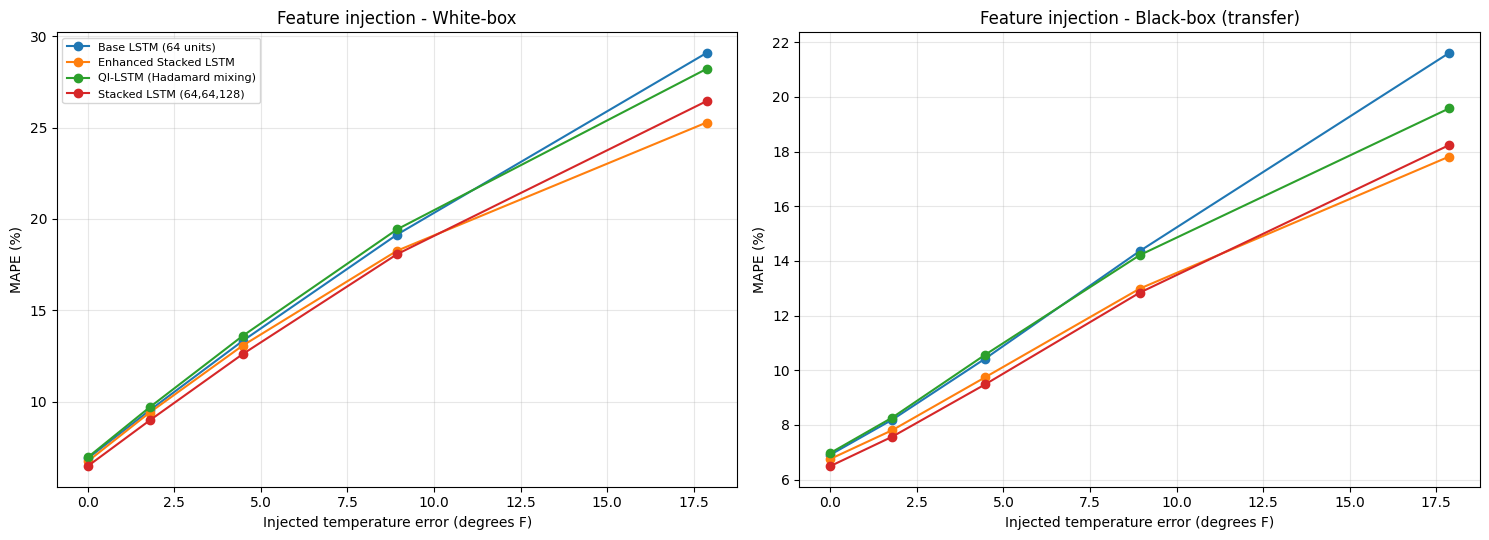

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for setting, ax in zip(["White-box", "Black-box (transfer)"], axes):
    sub = inj_pivot.xs(setting, level="setting")
    for model_name, row in sub.iterrows():
        ax.plot([0] + [e * drybulb_sigma_F for e in INJECTION_EPS],
                row.values, marker="o", label=model_name)
    ax.set_xlabel("Injected temperature error (degrees F)")
    ax.set_ylabel("MAPE (%)")
    ax.set_title(f"Feature injection - {setting}")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()